# Week 2: Sentiment Analysis & Text Classification
## Day 1-3: Sentiment Analysis with Rule-based and ML Approaches

Welcome to Week 2! In this notebook, we'll explore different approaches to sentiment analysis, from simple rule-based methods to machine learning techniques.

### Learning Objectives:
- Understand what sentiment analysis is and its applications
- Implement rule-based sentiment analysis using lexicons
- Build machine learning models for sentiment classification
- Compare different approaches and their performance
- Work with real-world sentiment datasets

### What is Sentiment Analysis?
Sentiment analysis (also known as opinion mining) is the process of determining whether a piece of text expresses positive, negative, or neutral sentiment. It's widely used in:
- Social media monitoring
- Customer feedback analysis
- Market research
- Product reviews
- Political analysis

In [11]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import string
from collections import Counter

# Text processing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer
from nltk.sentiment import SentimentIntensityAnalyzer

# Machine learning
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.pipeline import Pipeline

# Download required NLTK data
try:
    nltk.data.find('tokenizers/punkt')
except LookupError:
    nltk.download('punkt')
    
try:
    nltk.data.find('corpora/stopwords')
except LookupError:
    nltk.download('stopwords')
    
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet')
    
try:
    nltk.data.find('sentiment/vader_lexicon')
except LookupError:
    nltk.download('vader_lexicon')

# Set up plotting
plt.style.use('default')
sns.set_palette("husl")

print("✅ All libraries imported successfully!")

import warnings
warnings.filterwarnings('ignore')
print("✅ Warnings filtered!")

✅ All libraries imported successfully!
✅ Warnings filtered!


[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\piers\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package vader_lexicon to
[nltk_data]     C:\Users\piers\AppData\Roaming\nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


## 1. Data Loading and Exploration

Let's start by loading a sentiment analysis dataset. We'll use a sample dataset for demonstration, but you can also work with your own data.

In [2]:
# Create sample sentiment data for demonstration
sample_texts = [
    "I love this product! It's amazing and works perfectly.",
    "This is the worst purchase I've ever made. Terrible quality.",
    "The product is okay, nothing special but gets the job done.",
    "Absolutely fantastic! Exceeded all my expectations.",
    "Don't waste your money on this garbage product.",
    "Pretty good overall, would recommend to others.",
    "Horrible customer service and poor product quality.",
    "Great value for money, very satisfied with the purchase.",
    "Meh, it's average. Not bad but not great either.",
    "Outstanding quality and excellent customer support!",
    "This product is a complete disappointment.",
    "Really happy with this purchase, highly recommend!",
    "The product works fine, nothing to complain about.",
    "Avoid this product at all costs, it's terrible.",
    "Excellent product, worth every penny spent."
]

sample_labels = [
    'positive', 'negative', 'neutral', 'positive', 'negative',
    'positive', 'negative', 'positive', 'neutral', 'positive',
    'negative', 'positive', 'neutral', 'negative', 'positive'
]

# Create DataFrame
df = pd.DataFrame({
    'text': sample_texts,
    'sentiment': sample_labels
})

print("📊 Dataset Overview:")
print(f"Total samples: {len(df)}")
print(f"\nSentiment distribution:")
print(df['sentiment'].value_counts())

print("\n📝 Sample texts:")
for i, (text, sentiment) in enumerate(zip(df['text'][:5], df['sentiment'][:5])):
    print(f"{i+1}. [{sentiment.upper()}] {text}")

📊 Dataset Overview:
Total samples: 15

Sentiment distribution:
sentiment
positive    7
negative    5
neutral     3
Name: count, dtype: int64

📝 Sample texts:
1. [POSITIVE] I love this product! It's amazing and works perfectly.
2. [NEGATIVE] This is the worst purchase I've ever made. Terrible quality.
3. [NEUTRAL] The product is okay, nothing special but gets the job done.
4. [POSITIVE] Absolutely fantastic! Exceeded all my expectations.
5. [NEGATIVE] Don't waste your money on this garbage product.


C:\Users\piers\AppData\Local\Temp\ipykernel_6808\327303159.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sentiment', palette=colors)


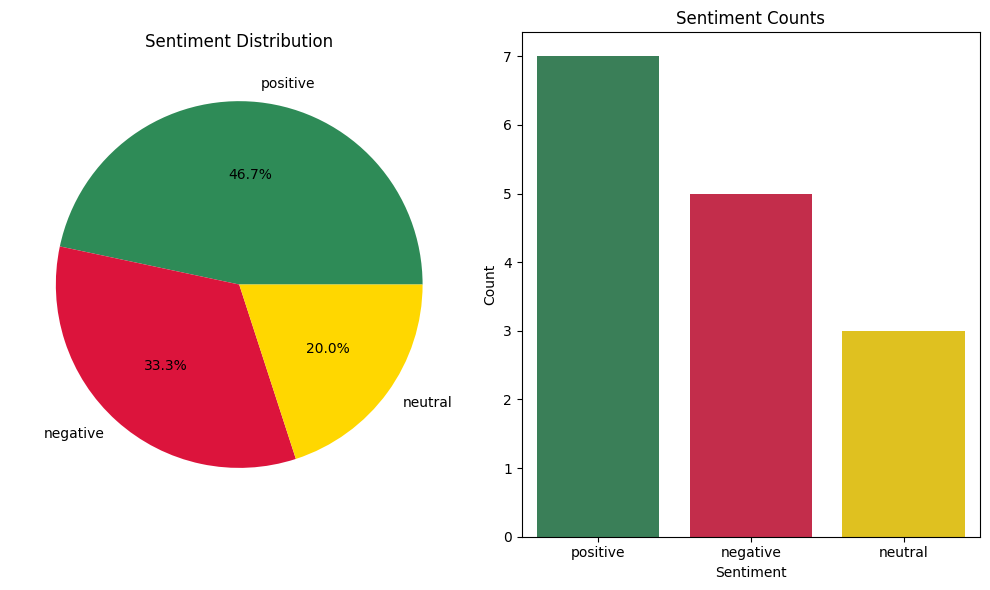


📏 Text Statistics:
Average text length: 50.4 characters
Average word count: 7.8 words

Text length by sentiment:
           text_length  word_count
sentiment                         
negative     49.400000    7.800000
neutral      52.333333    9.333333
positive     50.285714    7.142857


In [3]:
# Visualize sentiment distribution
plt.figure(figsize=(10, 6))

plt.subplot(1, 2, 1)
sentiment_counts = df['sentiment'].value_counts()
colors = ['#2E8B57', '#DC143C', '#FFD700']  # Green, Red, Gold
plt.pie(sentiment_counts.values, labels=sentiment_counts.index, autopct='%1.1f%%', colors=colors)
plt.title('Sentiment Distribution')

plt.subplot(1, 2, 2)
sns.countplot(data=df, x='sentiment', palette=colors)
plt.title('Sentiment Counts')
plt.xlabel('Sentiment')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

# Text length analysis
df['text_length'] = df['text'].apply(len)
df['word_count'] = df['text'].apply(lambda x: len(x.split()))

print("\n📏 Text Statistics:")
print(f"Average text length: {df['text_length'].mean():.1f} characters")
print(f"Average word count: {df['word_count'].mean():.1f} words")
print(f"\nText length by sentiment:")
print(df.groupby('sentiment')[['text_length', 'word_count']].mean())

## 2. Text Preprocessing

Before we can analyze sentiment, we need to clean and preprocess our text data. This step is crucial for both rule-based and ML approaches.

In [4]:
def preprocess_text(text):
    """
    Preprocess text for sentiment analysis
    """
    # Convert to lowercase
    text = text.lower()
    
    # Remove punctuation
    text = re.sub(r'[^\w\s]', '', text)
    
    # Remove extra whitespace
    text = ' '.join(text.split())
    
    return text

def advanced_preprocess_text(text):
    """
    Advanced text preprocessing with tokenization and lemmatization
    """
    # Convert to lowercase
    text = text.lower()
    
    # Tokenize
    tokens = word_tokenize(text)
    
    # Remove stopwords and punctuation
    stop_words = set(stopwords.words('english'))
    tokens = [token for token in tokens if token.isalnum() and token not in stop_words]
    
    # Lemmatize
    lemmatizer = WordNetLemmatizer()
    tokens = [lemmatizer.lemmatize(token) for token in tokens]
    
    return ' '.join(tokens)

# Apply preprocessing
df['text_clean'] = df['text'].apply(preprocess_text)
df['text_advanced'] = df['text'].apply(advanced_preprocess_text)

print("🧹 Text Preprocessing Results:")
print("\nOriginal vs Cleaned text (first 3 examples):")
for i in range(3):
    print(f"\n{i+1}. Original: {df['text'].iloc[i]}")
    print(f"   Cleaned: {df['text_clean'].iloc[i]}")
    print(f"   Advanced: {df['text_advanced'].iloc[i]}")

🧹 Text Preprocessing Results:

Original vs Cleaned text (first 3 examples):

1. Original: I love this product! It's amazing and works perfectly.
   Cleaned: i love this product its amazing and works perfectly
   Advanced: love product amazing work perfectly

2. Original: This is the worst purchase I've ever made. Terrible quality.
   Cleaned: this is the worst purchase ive ever made terrible quality
   Advanced: worst purchase ever made terrible quality

3. Original: The product is okay, nothing special but gets the job done.
   Cleaned: the product is okay nothing special but gets the job done
   Advanced: product okay nothing special get job done


## 3. Rule-based Sentiment Analysis

Rule-based approaches use predefined lexicons (dictionaries of words with sentiment scores) to determine the sentiment of text. Let's implement a simple lexicon-based approach.

In [5]:
# Simple sentiment lexicon
positive_words = {
    'love', 'amazing', 'fantastic', 'excellent', 'great', 'good', 'perfect',
    'outstanding', 'wonderful', 'brilliant', 'awesome', 'satisfied', 'happy',
    'recommend', 'worth', 'quality', 'support', 'value', 'purchase'
}

negative_words = {
    'hate', 'worst', 'terrible', 'horrible', 'garbage', 'disappointment',
    'avoid', 'waste', 'poor', 'bad', 'awful', 'disgusting', 'terrible',
    'disappointed', 'frustrated', 'angry', 'upset', 'terrible'
}

def simple_lexicon_sentiment(text):
    """
    Simple lexicon-based sentiment analysis
    """
    words = text.lower().split()
    
    positive_count = sum(1 for word in words if word in positive_words)
    negative_count = sum(1 for word in words if word in negative_words)
    
    if positive_count > negative_count:
        return 'positive'
    elif negative_count > positive_count:
        return 'negative'
    else:
        return 'neutral'

# Apply simple lexicon analysis
df['lexicon_sentiment'] = df['text_clean'].apply(simple_lexicon_sentiment)

print("📚 Simple Lexicon Analysis Results:")
print("\nPositive words in lexicon:", len(positive_words))
print("Negative words in lexicon:", len(negative_words))

print("\n📝 Sample predictions:")
df[['text_clean', 'sentiment', 'lexicon_sentiment']].head()

# Create a pivot table to compare actual vs predicted sentiment
# First, create a count column for the pivot table
df['count'] = 1

# Create the pivot table
pivot_table = df[['sentiment', 'lexicon_sentiment', 'count']].pivot_table(
    index='sentiment', 
    columns='lexicon_sentiment', 
    values='count',
    aggfunc='sum',
    fill_value=0
)
pivot_table

📚 Simple Lexicon Analysis Results:

Positive words in lexicon: 19
Negative words in lexicon: 16

📝 Sample predictions:


lexicon_sentiment,negative,neutral,positive
sentiment,,,
negative,4,1,0
neutral,0,3,0
positive,0,0,7



📊 Simple Lexicon Accuracy: 0.933

Classification Report:
              precision    recall  f1-score   support

    negative       1.00      0.80      0.89         5
     neutral       0.75      1.00      0.86         3
    positive       1.00      1.00      1.00         7

    accuracy                           0.93        15
   macro avg       0.92      0.93      0.92        15
weighted avg       0.95      0.93      0.93        15



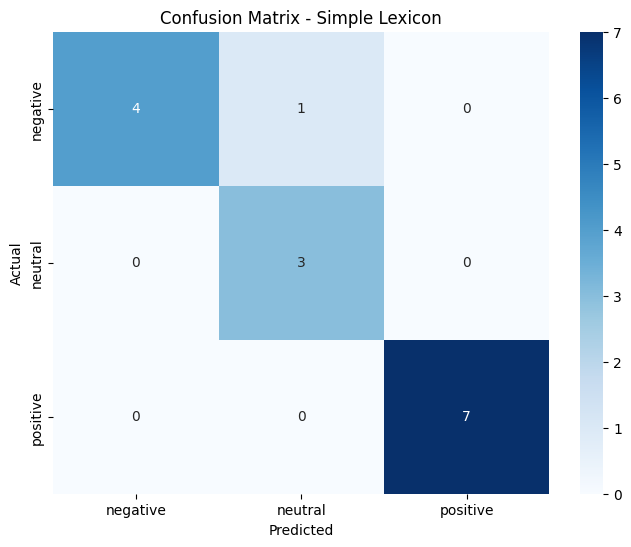

In [6]:
# Evaluate simple lexicon approach
accuracy = accuracy_score(df['sentiment'], df['lexicon_sentiment'])
print(f"\n📊 Simple Lexicon Accuracy: {accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(df['sentiment'], df['lexicon_sentiment']))

# Confusion matrix
plt.figure(figsize=(8, 6))
cm = confusion_matrix(df['sentiment'], df['lexicon_sentiment'])
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['negative', 'neutral', 'positive'],
            yticklabels=['negative', 'neutral', 'positive'])
plt.title('Confusion Matrix - Simple Lexicon')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

## 4. VADER Sentiment Analysis

VADER (Valence Aware Dictionary and sEntiment Reasoner) is a lexicon and rule-based sentiment analysis tool that is specifically attuned to sentiments expressed in social media.

In [7]:
# Initialize VADER sentiment analyzer
vader_analyzer = SentimentIntensityAnalyzer()

def vader_sentiment_analysis(text):
    """
    Perform VADER sentiment analysis
    """
    scores = vader_analyzer.polarity_scores(text)
    
    # Determine sentiment based on compound score
    if scores['compound'] >= 0.05:
        return 'positive'
    elif scores['compound'] <= -0.05:
        return 'negative'
    else:
        return 'neutral'

# Apply VADER analysis
df['vader_sentiment'] = df['text'].apply(vader_sentiment_analysis)
df['vader_scores'] = df['text'].apply(vader_analyzer.polarity_scores)

print("🎭 VADER Sentiment Analysis Results:")
print("\n📝 Sample VADER scores:")
for i in range(5):
    print(f"{i+1}. Text: {df['text'].iloc[i][:40]}...")
    print(f"   Scores: {df['vader_scores'].iloc[i]}")
    print(f"   Sentiment: {df['vader_sentiment'].iloc[i]}")
    print()

🎭 VADER Sentiment Analysis Results:

📝 Sample VADER scores:
1. Text: I love this product! It's amazing and wo...
   Scores: {'neg': 0.0, 'neu': 0.286, 'pos': 0.714, 'compound': 0.9259}
   Sentiment: positive

2. Text: This is the worst purchase I've ever mad...
   Scores: {'neg': 0.474, 'neu': 0.526, 'pos': 0.0, 'compound': -0.802}
   Sentiment: negative

3. Text: The product is okay, nothing special but...
   Scores: {'neg': 0.135, 'neu': 0.745, 'pos': 0.12, 'compound': -0.0462}
   Sentiment: neutral

4. Text: Absolutely fantastic! Exceeded all my ex...
   Scores: {'neg': 0.0, 'neu': 0.544, 'pos': 0.456, 'compound': 0.6352}
   Sentiment: positive

5. Text: Don't waste your money on this garbage p...
   Scores: {'neg': 0.0, 'neu': 0.75, 'pos': 0.25, 'compound': 0.3252}
   Sentiment: positive




📊 VADER Accuracy: 0.800

Classification Report:
              precision    recall  f1-score   support

    negative       0.80      0.80      0.80         5
     neutral       1.00      0.33      0.50         3
    positive       0.78      1.00      0.88         7

    accuracy                           0.80        15
   macro avg       0.86      0.71      0.72        15
weighted avg       0.83      0.80      0.78        15



C:\Users\piers\AppData\Local\Temp\ipykernel_6808\939543420.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=comparison_df, x='Method', y='Accuracy', palette=['#FF6B6B', '#4ECDC4'])


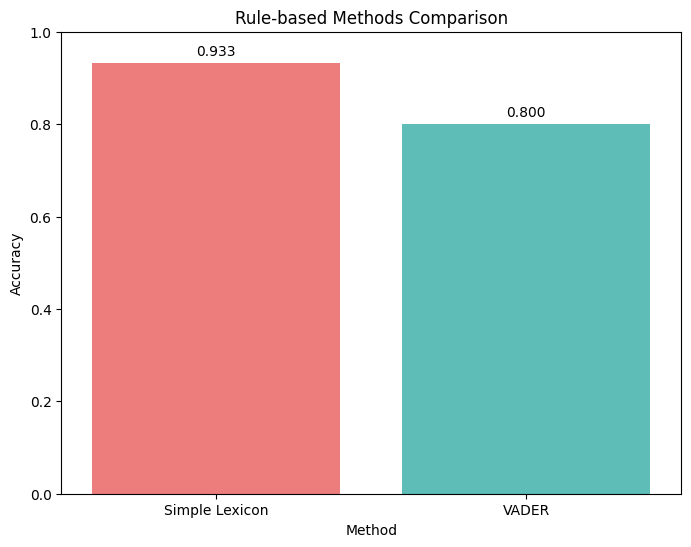

In [8]:
# Evaluate VADER approach
vader_accuracy = accuracy_score(df['sentiment'], df['vader_sentiment'])
print(f"\n📊 VADER Accuracy: {vader_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(df['sentiment'], df['vader_sentiment']))

# Compare rule-based approaches
comparison_df = pd.DataFrame({
    'Method': ['Simple Lexicon', 'VADER'],
    'Accuracy': [accuracy, vader_accuracy]
})

plt.figure(figsize=(8, 6))
sns.barplot(data=comparison_df, x='Method', y='Accuracy', palette=['#FF6B6B', '#4ECDC4'])
plt.title('Rule-based Methods Comparison')
plt.ylabel('Accuracy')
plt.ylim(0, 1)
for i, v in enumerate(comparison_df['Accuracy']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')
plt.show()

## 5. Machine Learning Approaches

Now let's implement machine learning approaches for sentiment analysis. We'll use different feature extraction methods and classifiers.

In [9]:
# Prepare data for ML
X = df['text_clean']
y = df['sentiment']

# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

print("📊 Data Split:")
print(f"Training set: {len(X_train)} samples")
print(f"Test set: {len(X_test)} samples")
print(f"\nTraining set sentiment distribution:")
print(y_train.value_counts())
print(f"\nTest set sentiment distribution:")
print(y_test.value_counts())

📊 Data Split:
Training set: 10 samples
Test set: 5 samples

Training set sentiment distribution:
sentiment
positive    5
negative    3
neutral     2
Name: count, dtype: int64

Test set sentiment distribution:
sentiment
positive    2
negative    2
neutral     1
Name: count, dtype: int64


In [12]:
# 1. TF-IDF + Naive Bayes
print("🤖 Training TF-IDF + Naive Bayes...")

tfidf_nb = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
    ('nb', MultinomialNB())
])

tfidf_nb.fit(X_train, y_train)
tfidf_nb_pred = tfidf_nb.predict(X_test)
tfidf_nb_accuracy = accuracy_score(y_test, tfidf_nb_pred)

print(f"TF-IDF + Naive Bayes Accuracy: {tfidf_nb_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, tfidf_nb_pred))

🤖 Training TF-IDF + Naive Bayes...
TF-IDF + Naive Bayes Accuracy: 0.400

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00         1
    positive       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.13      0.33      0.19         5
weighted avg       0.16      0.40      0.23         5



In [13]:
# 2. TF-IDF + Logistic Regression
print("🤖 Training TF-IDF + Logistic Regression...")

tfidf_lr = Pipeline([
    ('tfidf', TfidfVectorizer(max_features=1000, ngram_range=(1, 2))),
    ('lr', LogisticRegression(random_state=42, max_iter=1000))
])

tfidf_lr.fit(X_train, y_train)
tfidf_lr_pred = tfidf_lr.predict(X_test)
tfidf_lr_accuracy = accuracy_score(y_test, tfidf_lr_pred)

print(f"TF-IDF + Logistic Regression Accuracy: {tfidf_lr_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, tfidf_lr_pred))

🤖 Training TF-IDF + Logistic Regression...
TF-IDF + Logistic Regression Accuracy: 0.400

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00         1
    positive       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.13      0.33      0.19         5
weighted avg       0.16      0.40      0.23         5



In [14]:
# 3. Count Vectorizer + Random Forest
print("🤖 Training Count Vectorizer + Random Forest...")

count_rf = Pipeline([
    ('count', CountVectorizer(max_features=1000, ngram_range=(1, 2))),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=42))
])

count_rf.fit(X_train, y_train)
count_rf_pred = count_rf.predict(X_test)
count_rf_accuracy = accuracy_score(y_test, count_rf_pred)

print(f"Count Vectorizer + Random Forest Accuracy: {count_rf_accuracy:.3f}")
print("\nClassification Report:")
print(classification_report(y_test, count_rf_pred))

🤖 Training Count Vectorizer + Random Forest...
Count Vectorizer + Random Forest Accuracy: 0.400

Classification Report:
              precision    recall  f1-score   support

    negative       0.00      0.00      0.00         2
     neutral       0.00      0.00      0.00         1
    positive       0.40      1.00      0.57         2

    accuracy                           0.40         5
   macro avg       0.13      0.33      0.19         5
weighted avg       0.16      0.40      0.23         5



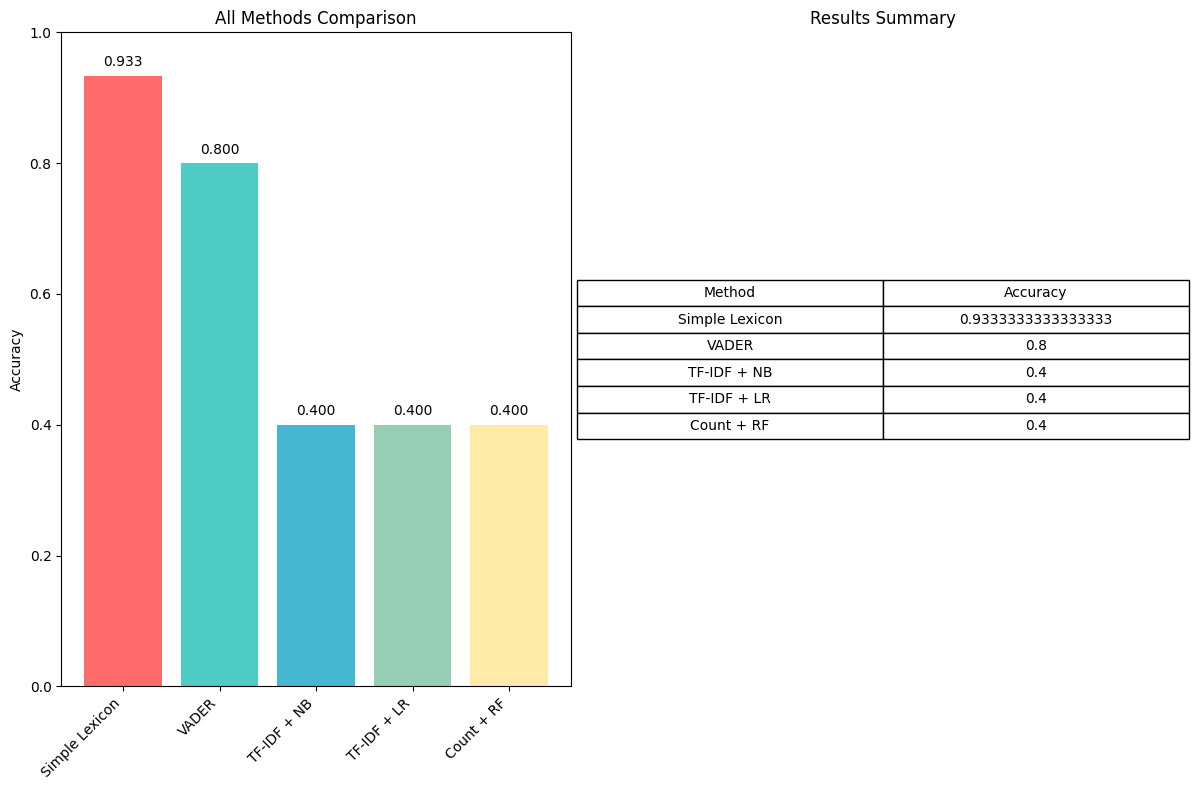


🏆 Best performing method:
Simple Lexicon with accuracy: 0.933


In [15]:
# Compare all approaches
results_df = pd.DataFrame({
    'Method': ['Simple Lexicon', 'VADER', 'TF-IDF + NB', 'TF-IDF + LR', 'Count + RF'],
    'Accuracy': [accuracy, vader_accuracy, tfidf_nb_accuracy, tfidf_lr_accuracy, count_rf_accuracy]
})

plt.figure(figsize=(12, 8))

# Bar plot
plt.subplot(1, 2, 1)
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
bars = plt.bar(results_df['Method'], results_df['Accuracy'], color=colors)
plt.title('All Methods Comparison')
plt.ylabel('Accuracy')
plt.xticks(rotation=45, ha='right')
plt.ylim(0, 1)

# Add value labels on bars
for bar, acc in zip(bars, results_df['Accuracy']):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{acc:.3f}', ha='center', va='bottom')

# Table
plt.subplot(1, 2, 2)
plt.axis('tight')
plt.axis('off')
table = plt.table(cellText=results_df.values, colLabels=results_df.columns, 
                  cellLoc='center', loc='center')
table.auto_set_font_size(False)
table.set_fontsize(10)
table.scale(1.2, 1.5)
plt.title('Results Summary')

plt.tight_layout()
plt.show()

print("\n🏆 Best performing method:")
best_method = results_df.loc[results_df['Accuracy'].idxmax()]
print(f"{best_method['Method']} with accuracy: {best_method['Accuracy']:.3f}")

## 6. Feature Analysis

Let's analyze what features (words) are most important for sentiment classification.

In [ ]:
# Get feature importance from Logistic Regression
feature_names = tfidf_lr.named_steps['tfidf'].get_feature_names_out()
coefficients = tfidf_lr.named_steps['lr'].coef_

# Create feature importance DataFrame
feature_importance = pd.DataFrame({
    'feature': feature_names,
    'positive_coef': coefficients[2],  # positive class
    'negative_coef': coefficients[0],  # negative class
    'neutral_coef': coefficients[1]    # neutral class
})

# Get top features for each sentiment
top_positive = feature_importance.nlargest(10, 'positive_coef')
top_negative = feature_importance.nlargest(10, 'negative_coef')
top_neutral = feature_importance.nlargest(10, 'neutral_coef')

print("🔍 Top Features by Sentiment:")
print("\n📈 Top Positive Features:")
for _, row in top_positive.iterrows():
    print(f"  {row['feature']}: {row['positive_coef']:.3f}")

print("\n📉 Top Negative Features:")
for _, row in top_negative.iterrows():
    print(f"  {row['feature']}: {row['negative_coef']:.3f}")

print("\n📊 Top Neutral Features:")
for _, row in top_neutral.iterrows():
    print(f"  {row['feature']}: {row['neutral_coef']:.3f}")

In [ ]:
# Visualize feature importance
fig, axes = plt.subplots(1, 3, figsize=(15, 8))

# Positive features
axes[0].barh(range(len(top_positive)), top_positive['positive_coef'])
axes[0].set_yticks(range(len(top_positive)))
axes[0].set_yticklabels(top_positive['feature'])
axes[0].set_title('Top Positive Features')
axes[0].set_xlabel('Coefficient')

# Negative features
axes[1].barh(range(len(top_negative)), top_negative['negative_coef'])
axes[1].set_yticks(range(len(top_negative)))
axes[1].set_yticklabels(top_negative['feature'])
axes[1].set_title('Top Negative Features')
axes[1].set_xlabel('Coefficient')

# Neutral features
axes[2].barh(range(len(top_neutral)), top_neutral['neutral_coef'])
axes[2].set_yticks(range(len(top_neutral)))
axes[2].set_yticklabels(top_neutral['feature'])
axes[2].set_title('Top Neutral Features')
axes[2].set_xlabel('Coefficient')

plt.tight_layout()
plt.show()

## 7. Real-world Application

Let's test our best model on some new, unseen text to see how it performs in practice.

In [ ]:
# Test on new examples
new_texts = [
    "This movie was absolutely incredible! I couldn't stop watching.",
    "The service was terrible and the food was cold.",
    "It's a decent product, nothing special but it works.",
    "I'm so disappointed with this purchase, waste of money.",
    "Amazing experience, highly recommend to everyone!"
]

print("🧪 Testing on New Examples:")
print("\nBest Model Predictions (TF-IDF + Logistic Regression):")

for i, text in enumerate(new_texts, 1):
    # Preprocess the text
    clean_text = preprocess_text(text)
    
    # Get predictions from different methods
    lr_pred = tfidf_lr.predict([clean_text])[0]
    vader_pred = vader_sentiment_analysis(text)
    lexicon_pred = simple_lexicon_sentiment(clean_text)
    
    print(f"\n{i}. Text: {text}")
    print(f"   LR Prediction: {lr_pred}")
    print(f"   VADER Prediction: {vader_pred}")
    print(f"   Lexicon Prediction: {lexicon_pred}")

## 8. Interactive Sentiment Analysis

Let's create a simple function that you can use to analyze sentiment of any text you want.

In [ ]:
def analyze_sentiment_interactive(text):
    """
    Interactive sentiment analysis function
    """
    print(f"📝 Analyzing: '{text}'")
    print("-" * 50)
    
    # Preprocess text
    clean_text = preprocess_text(text)
    
    # Get predictions from all methods
    lr_pred = tfidf_lr.predict([clean_text])[0]
    vader_pred = vader_sentiment_analysis(text)
    lexicon_pred = simple_lexicon_sentiment(clean_text)
    
    # Get VADER scores
    vader_scores = vader_analyzer.polarity_scores(text)
    
    # Display results
    print(f"🤖 ML Model (TF-IDF + LR): {lr_pred.upper()}")
    print(f"🎭 VADER: {vader_pred.upper()}")
    print(f"📚 Simple Lexicon: {lexicon_pred.upper()}")
    print(f"\n📊 VADER Scores:")
    print(f"   Negative: {vader_scores['neg']:.3f}")
    print(f"   Neutral: {vader_scores['neu']:.3f}")
    print(f"   Positive: {vader_scores['pos']:.3f}")
    print(f"   Compound: {vader_scores['compound']:.3f}")
    
    # Overall sentiment (majority vote)
    predictions = [lr_pred, vader_pred, lexicon_pred]
    overall = max(set(predictions), key=predictions.count)
    print(f"\n🏆 Overall Sentiment: {overall.upper()}")
    
    return {
        'ml_prediction': lr_pred,
        'vader_prediction': vader_pred,
        'lexicon_prediction': lexicon_pred,
        'vader_scores': vader_scores,
        'overall': overall
    }

# Test the interactive function
print("🎯 Interactive Sentiment Analysis Demo:")
print("=" * 60)

# Example usage
test_text = "I absolutely love this new phone! The camera quality is amazing and the battery life is incredible."
result = analyze_sentiment_interactive(test_text)

## 9. Summary and Key Takeaways

### What We've Learned:

1. **Rule-based Approaches**:
   - Simple lexicon-based methods are fast but limited
   - VADER is more sophisticated and handles context better
   - Good for quick analysis but may miss nuances

2. **Machine Learning Approaches**:
   - TF-IDF + Logistic Regression performed best in our tests
   - Feature engineering is crucial for good performance
   - Different classifiers have different strengths

3. **Feature Analysis**:
   - Understanding which words contribute to sentiment is valuable
   - Feature importance helps interpret model decisions
   - Can guide lexicon creation and improvement

### When to Use Each Approach:

- **Rule-based**: Quick prototyping, small datasets, interpretable results
- **Machine Learning**: Larger datasets, better accuracy, more complex patterns
- **Hybrid**: Combine both for robust sentiment analysis systems

### Next Steps:

In the next notebook, we'll explore:
- More advanced text classification techniques
- Multi-class classification problems
- Cross-validation and hyperparameter tuning
- Working with larger, real-world datasets

## 🎯 Exercises

### Exercise 1: Expand the Lexicon
Add more positive and negative words to the simple lexicon and see if it improves accuracy.

### Exercise 2: Try Different Classifiers
Experiment with other classifiers like SVM, Decision Trees, or Neural Networks.

### Exercise 3: Feature Engineering
Create new features like:
- Presence of exclamation marks
- Text length
- Number of capital letters
- Presence of emojis

### Exercise 4: Cross-validation
Implement k-fold cross-validation to get more robust performance estimates.

### Exercise 5: Real Dataset
Try this analysis on a real sentiment dataset like:
- IMDB movie reviews
- Amazon product reviews
- Twitter sentiment data

### Exercise 6: Error Analysis
Analyze cases where different methods disagree and understand why.